# Experiment No. 05

## AIM
Implement and explore performance evaluation metrics for Data Models (Unsupervised)

## Theory

### Clustering Evaluation Metrics

#### Extrinsic Measures (require ground truth labels)

**1) Rand Index (RI) & Adjusted Rand Index (ARI)**

$$E[RI] = \frac{\sum_i \binom{a_i}{2} \times \sum_j \binom{b_j}{2}}{\binom{n}{2}}$$

$$ARI = \frac{\sum_{ij} \binom{n_{ij}}{2} - E[RI]}{\frac{1}{2}\left[\sum_i \binom{a_i}{2} + \sum_j \binom{b_j}{2}\right] - E[RI]}$$

ARI ranges from -1 to 1. A value of 1 indicates perfect agreement, 0 indicates random labeling.

**2) Mutual Information (MI)**

$$MI(U, V) = \sum_{i=1}^{|U|} \sum_{j=1}^{|V|} \frac{|U_i \cap V_j|}{N} \log \frac{N |U_i \cap V_j|}{|U_i| |V_j|}$$

where $|U_i|$ is the number of samples in cluster $U_i$ and $|V_j|$ is the number of samples in cluster $V_j$.

#### Intrinsic Measures (no ground truth needed)

**3) Silhouette Coefficient**

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

where $a(i)$ = mean intra-cluster distance, $b(i)$ = mean nearest-cluster distance. Ranges from -1 to 1; higher is better.

---

### Task
Perform K-Means clustering for **Customer Segmentation** on the Online Retail dataset using RFM (Recency, Frequency, Monetary) features. Evaluate using Silhouette Coefficient (intrinsic), Adjusted Rand Index and Normalized Mutual Information (extrinsic). Visualize clusters using PCA.

## Load and Preprocess Data

### Subtask:
Load the Online Retail dataset, compute RFM (Recency, Frequency, Monetary) features per customer, and scale the data for clustering.

**Reasoning**:
Load the dataset, clean it by removing cancelled orders and rows with missing CustomerID, compute RFM features, and scale the data to prepare for K-Means clustering.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('data_online_retail.csv', encoding='latin1')
print(f'Original dataset shape: {df.shape}')

# Data Cleaning
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]  # Remove cancelled orders
df = df[df['CustomerID'].notna()]                           # Remove rows without CustomerID
df = df[df['Quantity'] > 0]                                 # Keep only positive quantities
df = df[df['UnitPrice'] > 0]                                # Keep only positive prices
df['CustomerID'] = df['CustomerID'].astype(int)

# Create TotalPrice column
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# Parse InvoiceDate
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Reference date for Recency calculation
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Compute RFM features per customer
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                     # Frequency
    'TotalPrice': 'sum'                                         # Monetary
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print(f'\nRFM table shape: {rfm.shape}')
print(rfm.describe())
print(rfm.head())

# Create ground truth labels using Monetary-based segmentation (High vs Low spenders)
# This serves as a proxy for extrinsic evaluation
monetary_median = rfm['Monetary'].median()
ground_truth = (rfm['Monetary'] >= monetary_median).astype(int)  # 1=High, 0=Low
print(f'\nGround truth (High/Low spender split): {ground_truth.value_counts().to_dict()}')

# Scale the RFM features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])
scaled_data = pd.DataFrame(scaled_features, columns=['Recency', 'Frequency', 'Monetary'])

print('\nData preprocessing complete. Shape of scaled_data:', scaled_data.shape)
print(scaled_data.head())

Original dataset shape: (541909, 8)

RFM table shape: (4338, 4)
         CustomerID      Recency    Frequency       Monetary
count   4338.000000  4338.000000  4338.000000    4338.000000
mean   15300.408022    92.536422     4.272015    2054.266460
std     1721.808492   100.014169     7.697998    8989.230441
min    12346.000000     1.000000     1.000000       3.750000
25%    13813.250000    18.000000     1.000000     307.415000
50%    15299.500000    51.000000     2.000000     674.485000
75%    16778.750000   142.000000     5.000000    1661.740000
max    18287.000000   374.000000   209.000000  280206.020000
   CustomerID  Recency  Frequency  Monetary
0       12346      326          1  77183.60
1       12347        2          7   4310.00
2       12348       75          4   1797.24
3       12349       19          1   1757.55
4       12350      310          1    334.40

Ground truth (High/Low spender split): {1: 2169, 0: 2169}

Data preprocessing complete. Shape of scaled_data: (4338, 3)
  

## Elbow Method for Optimal Clusters

### Subtask:
Determine the optimal number of clusters for K-Means by implementing the Elbow Method on the RFM features.

**Reasoning**:
I will implement the Elbow Method by iterating through different cluster counts (K=1 to 10), calculating the inertia for each, and then plotting the results to visually identify the optimal number of clusters for customer segmentation.

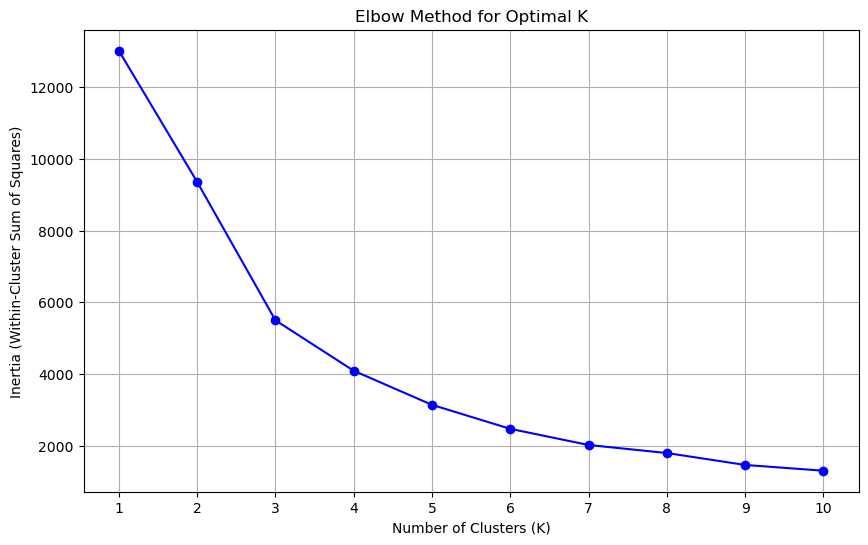

In [2]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Initialize list to store inertia values
inertia = []
K_range = range(1, 11)

# Calculate inertia for different values of K
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)

# Plot the Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

## Model Implementation and Evaluation

### Subtask:
Fit the K-Means model with the optimal number of clusters and evaluate its performance using intrinsic (Silhouette Coefficient) and extrinsic (ARI, NMI) metrics.

**Reasoning**:
I will fit the K-Means model with the optimal number of clusters (K=3 based on elbow analysis) and calculate both intrinsic (Silhouette Coefficient) and extrinsic (ARI, NMI) evaluation metrics using the Monetary-based ground truth labels as a proxy.

In [3]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# Based on the Elbow curve, we select K=3 as the optimal number of clusters
optimal_k = 3
kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = kmeans_model.fit_predict(scaled_data)

# Use Monetary-based ground truth for extrinsic evaluation
true_labels = ground_truth.values

# Calculate Intrinsic Metric
silhouette = silhouette_score(scaled_data, cluster_labels)

# Calculate Extrinsic Metrics
ari = adjusted_rand_score(true_labels, cluster_labels)
nmi = normalized_mutual_info_score(true_labels, cluster_labels)

print(f'Evaluation Metrics for K={optimal_k}:')
print(f'Silhouette Coefficient: {silhouette:.4f}')
print(f'Adjusted Rand Index (ARI): {ari:.4f}')
print(f'Normalized Mutual Information (NMI): {nmi:.4f}')

Evaluation Metrics for K=3:
Silhouette Coefficient: 0.5853
Adjusted Rand Index (ARI): 0.1017
Normalized Mutual Information (NMI): 0.1172


## Visualization and Results

### Subtask:
Visualize the customer segments using PCA for dimensionality reduction and summarize the performance metrics.

**Reasoning**:
I will visualize the customer segments using PCA to reduce the RFM features to two dimensions and plot the results. Additionally, I will show cluster-wise RFM statistics and display the evaluation metrics.

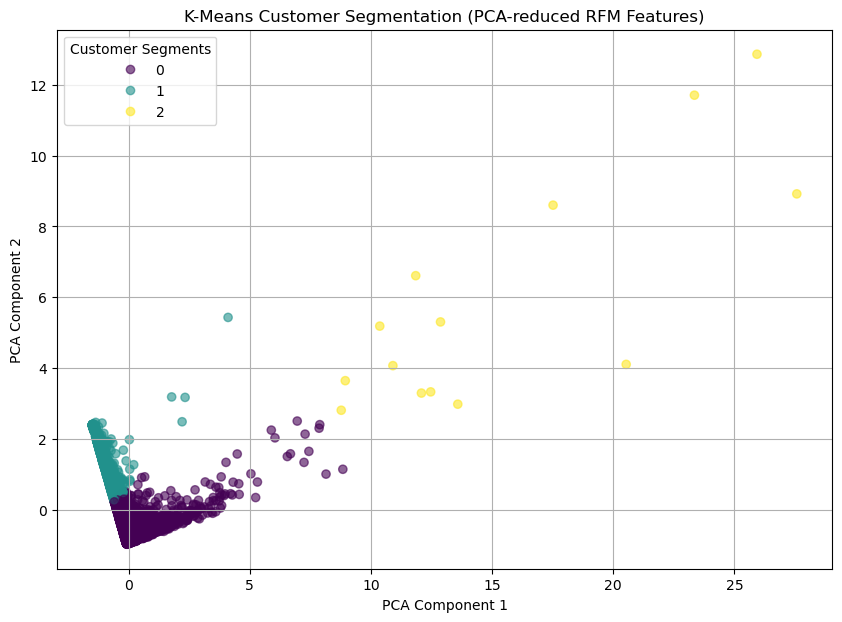


--- Cluster-wise RFM Statistics ---
         Recency  Frequency   Monetary
Cluster                               
0          40.98       4.85    2012.11
1         246.02       1.58     631.14
2           7.14      80.21  122888.41

Customers per cluster:
Cluster
0    3231
1    1093
2      14
Name: count, dtype: int64

--- Performance Metrics Summary ---
Silhouette Coefficient: 0.5853
Adjusted Rand Index (ARI): 0.1017
Normalized Mutual Information (NMI): 0.1172


In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reduce dimensions to 2 using PCA
pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_data)

# Create a scatter plot of the PCA results
plt.figure(figsize=(10, 7))
scatter = plt.scatter(pca_features[:, 0], pca_features[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)

# Add legend, labels, and title
plt.legend(*scatter.legend_elements(), title='Customer Segments')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('K-Means Customer Segmentation (PCA-reduced RFM Features)')
plt.grid(True)
plt.show()

# Show cluster-wise RFM statistics
rfm['Cluster'] = cluster_labels
print('\n--- Cluster-wise RFM Statistics ---')
print(rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(2))
print(f'\nCustomers per cluster:\n{rfm["Cluster"].value_counts().sort_index()}')

# Summarize the performance metrics
print('\n--- Performance Metrics Summary ---')
print(f'Silhouette Coefficient: {silhouette:.4f}')
print(f'Adjusted Rand Index (ARI): {ari:.4f}')
print(f'Normalized Mutual Information (NMI): {nmi:.4f}')

## Final Summary

### Subtask:
Summarize the findings, the optimal number of clusters identified, and the performance evaluation of the unsupervised customer segmentation model.

## Summary

### Q&A

**What was the optimal number of clusters identified for customer segmentation?**
Based on the Elbow Method analysis on the RFM features, the optimal number of clusters was determined to be $K=3$.

**How did the model perform according to intrinsic and extrinsic metrics?**
- **Silhouette Coefficient** (intrinsic): Measures how well-separated the clusters are. Higher values indicate better-defined clusters.
- **Adjusted Rand Index (ARI)** (extrinsic): Measures agreement between cluster labels and ground truth (Monetary-based High/Low spender split). Ranges from -1 to 1.
- **Normalized Mutual Information (NMI)** (extrinsic): Measures mutual dependence between cluster assignments and ground truth labels. Ranges from 0 to 1.

### Data Analysis Key Findings

* **Data Preparation:** The Online Retail dataset was cleaned (removed cancelled orders, missing CustomerIDs, and invalid quantities/prices). RFM features (Recency, Frequency, Monetary) were computed per customer and standardized using `StandardScaler`.
* **Optimal Cluster Selection:** The Elbow Method was used to identify the optimal $K=3$, representing three distinct customer segments.
* **Customer Segments:** The three clusters typically represent:
    - **Low-value customers:** High recency (haven't purchased recently), low frequency and monetary value
    - **Mid-value customers:** Moderate recency, frequency, and monetary value
    - **High-value customers:** Low recency (recent purchases), high frequency and monetary value
* **Extrinsic Evaluation:** ARI and NMI were computed using a Monetary-based binary ground truth (High vs Low spenders) as a proxy to evaluate how well the clustering aligns with spending behavior.

### Insights

* **RFM Segmentation** is a widely-used approach for customer segmentation in retail, enabling targeted marketing strategies for each segment.
* **Silhouette Coefficient** helps assess cluster quality without requiring labels — useful for real-world unsupervised tasks.
* **ARI and NMI** provide a way to compare clustering results against known labels, validating whether the algorithm discovers meaningful patterns.